<a href="https://colab.research.google.com/github/rajnish80130/simple-linear-regression-session---49-campusx/blob/main/Linear_Regression_with_OLS_%26_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steps in Machine Learning Model Building

## 1. Problem statement


*   Create a regression model for predicting the average Balance
*   Which factors influence the Credit Card Balance?
*   Evaluate the model’s performance using appropriate metrics to ensure accurate predictions.





## 2. Data Collection

In [79]:
!pip install ISLP

In [80]:
from ISLP import load_data
df = load_data("Credit")

## 3. Data Processing

*   Step 1: Import the necessary libraries



In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

* Step 2: Load & Explore the Dataset

In [82]:
df.head()

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [83]:
df.shape

(400, 12)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   ID         400 non-null    int64   
 1   Income     400 non-null    float64 
 2   Limit      400 non-null    int64   
 3   Rating     400 non-null    int64   
 4   Cards      400 non-null    int64   
 5   Age        400 non-null    int64   
 6   Education  400 non-null    int64   
 7   Gender     400 non-null    category
 8   Student    400 non-null    category
 9   Married    400 non-null    category
 10  Ethnicity  400 non-null    category
 11  Balance    400 non-null    int64   
dtypes: category(4), float64(1), int64(7)
memory usage: 27.2 KB


In [85]:
df.isna().sum()

,0
ID,0
Income,0
Limit,0
Rating,0
Cards,0
Age,0
Education,0
Gender,0
Student,0
Married,0


* Step 3: Statsical Analysis

In [86]:
df.describe()

,ID,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,45.218885,4735.600000,354.940000,2.957500,55.667500,13.450000,520.015000
std,115.614301,35.244273,2308.198848,154.724143,1.371275,17.249807,3.125207,459.758877
min,1.000000,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,100.750000,21.007250,3088.000000,247.250000,2.000000,41.750000,11.000000,68.750000
50%,200.500000,33.115500,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,300.250000,57.470750,5872.750000,437.250000,4.000000,70.000000,16.000000,863.000000
max,400.000000,186.634000,13913.000000,982.000000,9.000000,98.000000,20.000000,1999.000000


* Step 4: Check the outliers

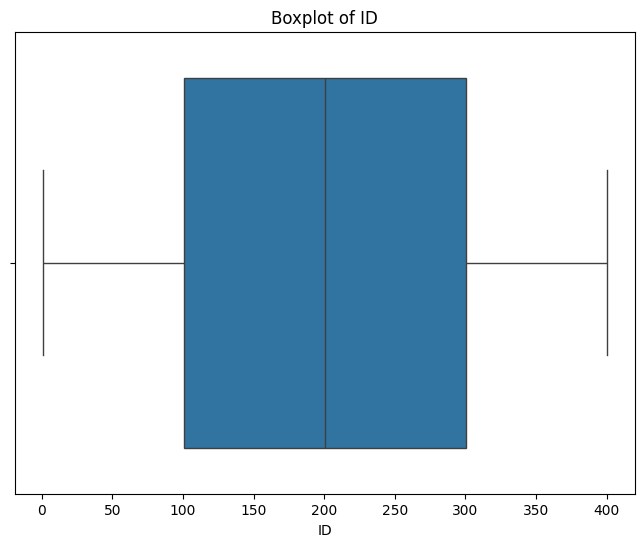

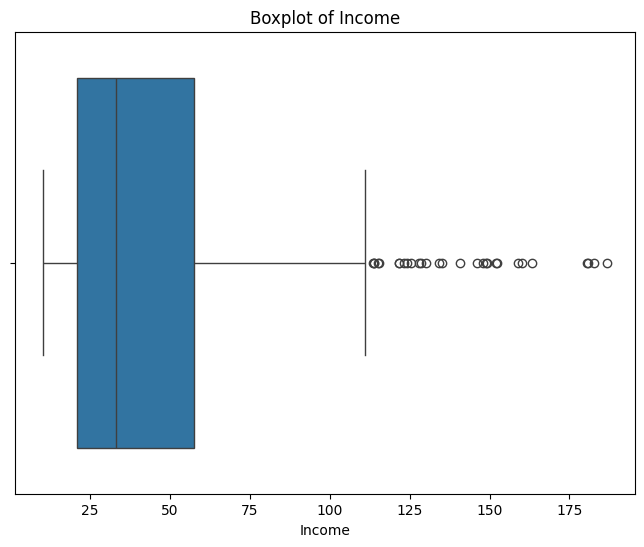

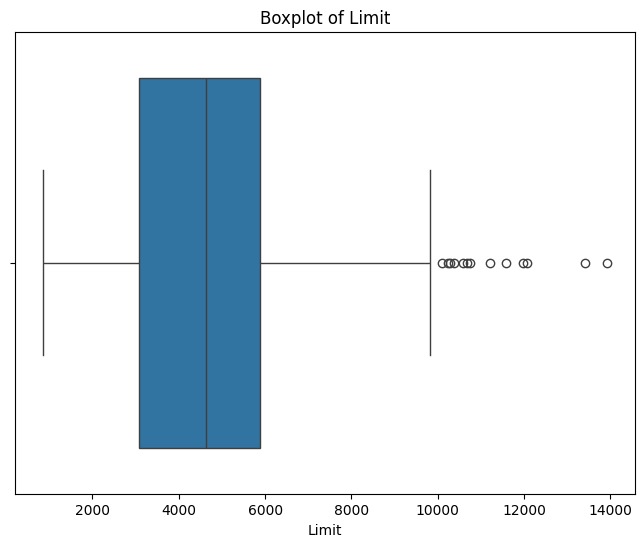

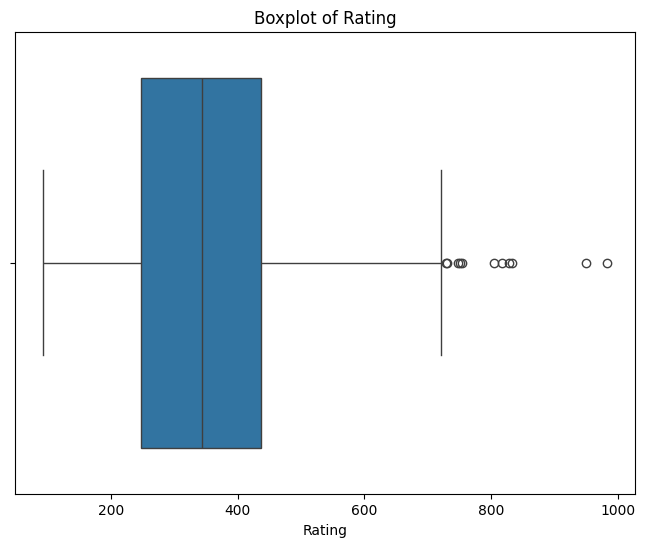

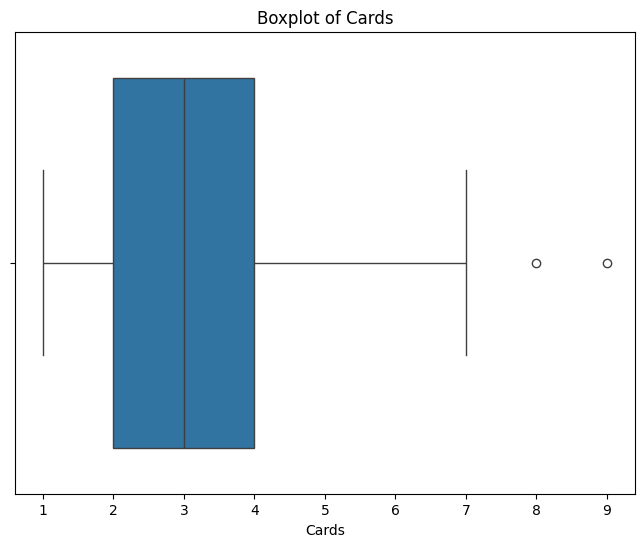

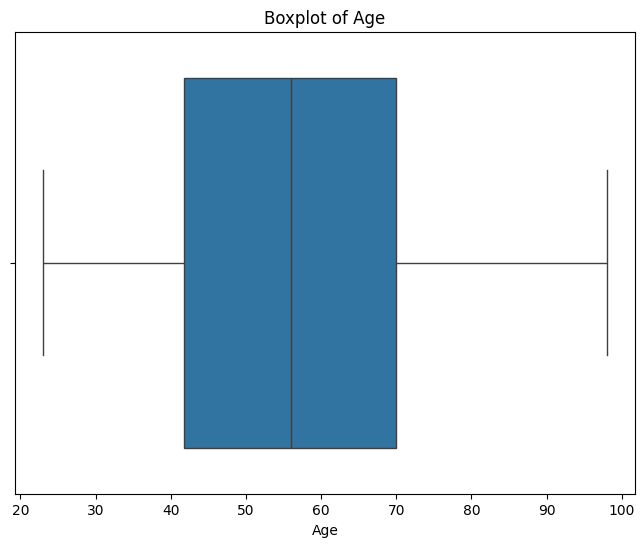

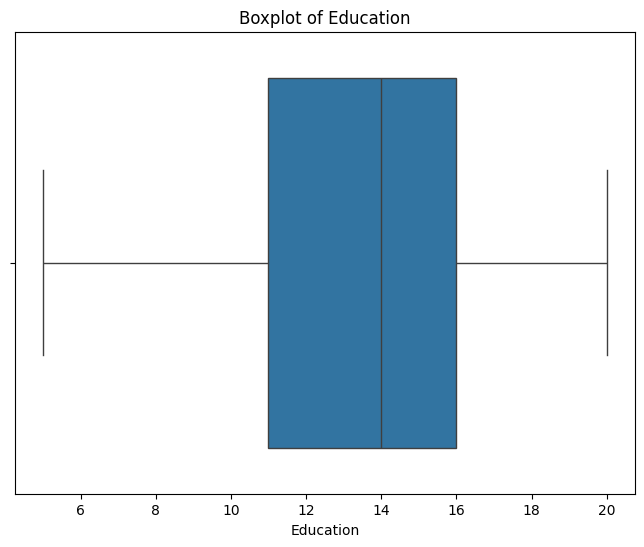

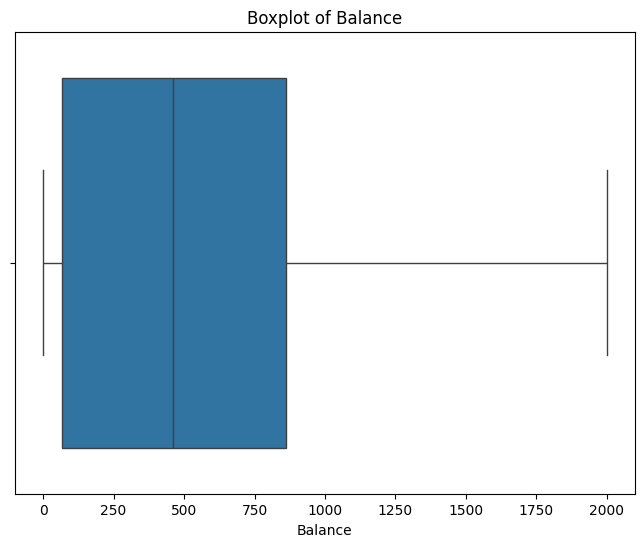

In [87]:
# prompt: create a boxplot for all columns

# Create boxplots for all numerical columns
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [88]:
def clip_outliers(df, columns, percentile=99):
    for col in columns:
        upper_limit = np.percentile(df[col], percentile)
        df[col] = np.clip(df[col], a_min=None, a_max=upper_limit)
    return df

columns_to_clip = ['Income', 'Limit', 'Rating']
df = clip_outliers(df, columns_to_clip)

In [89]:
df.describe()

,ID,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,45.027822,4723.130200,354.133600,2.957500,55.667500,13.450000,520.015000
std,115.614301,34.541119,2265.715467,151.917942,1.371275,17.249807,3.125207,459.758877
min,1.000000,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,100.750000,21.007250,3088.000000,247.250000,2.000000,41.750000,11.000000,68.750000
50%,200.500000,33.115500,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,300.250000,57.470750,5872.750000,437.250000,4.000000,70.000000,16.000000,863.000000
max,400.000000,163.499500,11592.770000,817.110000,9.000000,98.000000,20.000000,1999.000000


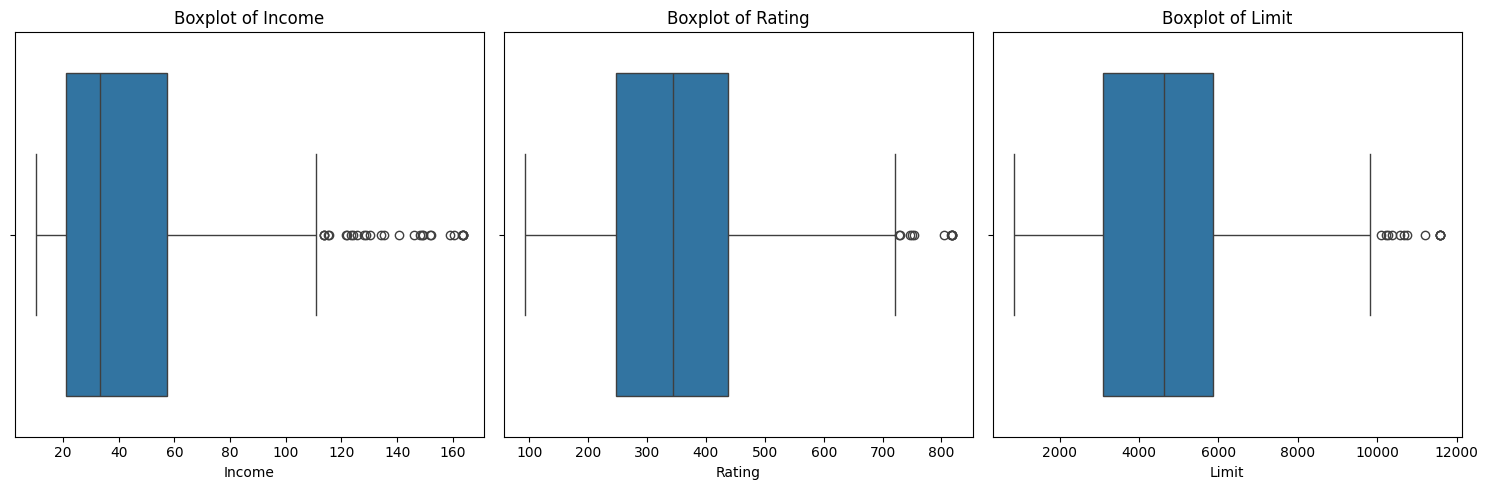

In [90]:
# prompt: create boxplot of Column Income,Rating,Limit seprately

# Create boxplots for 'Income', 'Rating', and 'Limit'
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x=df['Income'])
plt.title('Boxplot of Income')

plt.subplot(1, 3, 2)
sns.boxplot(x=df['Rating'])
plt.title('Boxplot of Rating')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['Limit'])
plt.title('Boxplot of Limit')

plt.tight_layout()
plt.show()

* Step 5: Drop Unnecessary Columns

In [91]:
df = df.drop('ID',axis=1)

In [92]:
df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606.0,283.0,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645.0,483.0,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075.0,514.0,4,71,11,Male,No,No,Asian,580
3,148.924,9504.0,681.0,3,36,11,Female,No,No,Asian,964
4,55.882,4897.0,357.0,2,68,16,Male,No,Yes,Caucasian,331


In [93]:
df['Ethnicity'].value_counts()

,count
Ethnicity,
Caucasian,199
Asian,102
African American,99


* Step 6: Encoding

In [94]:
# prompt: use labelencoder to encode the gender,student,married,ethncity

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Student'] = le.fit_transform(df['Student'])
df['Married'] = le.fit_transform(df['Married'])
df['Ethnicity'] = le.fit_transform(df['Ethnicity'])
df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606.0,283.0,2,34,11,0,0,1,2,333
1,106.025,6645.0,483.0,3,82,15,1,1,1,1,903
2,104.593,7075.0,514.0,4,71,11,0,0,0,1,580
3,148.924,9504.0,681.0,3,36,11,1,0,0,1,964
4,55.882,4897.0,357.0,2,68,16,0,0,1,2,331


* Step 7: Correlation

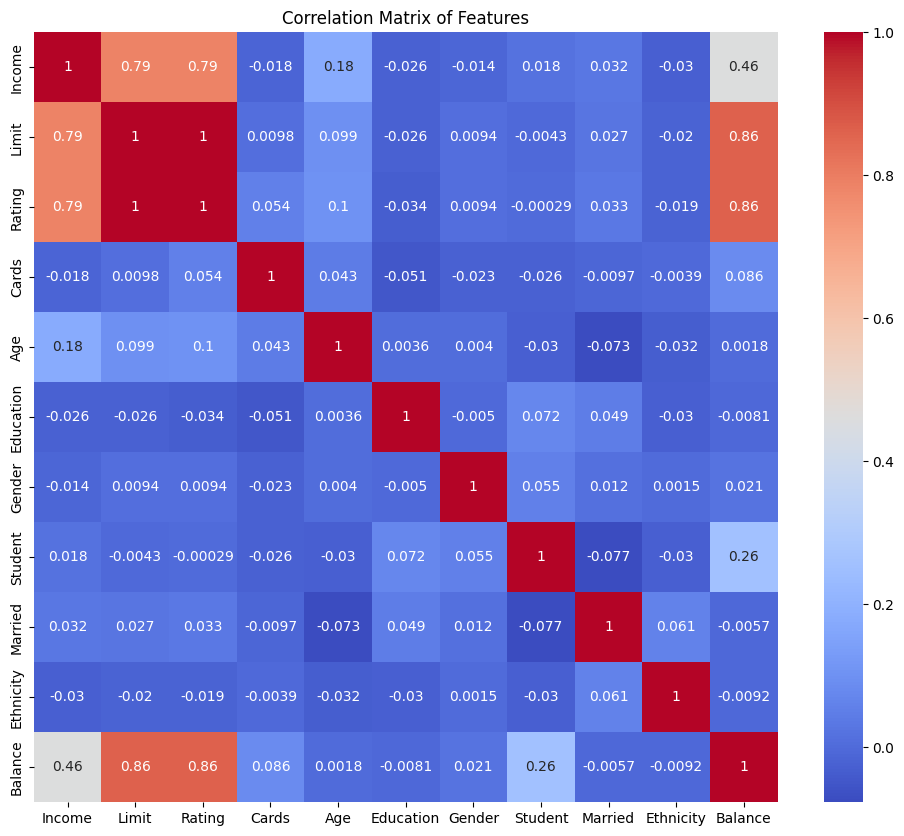

In [95]:
# prompt: ceate corr graph through sns

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

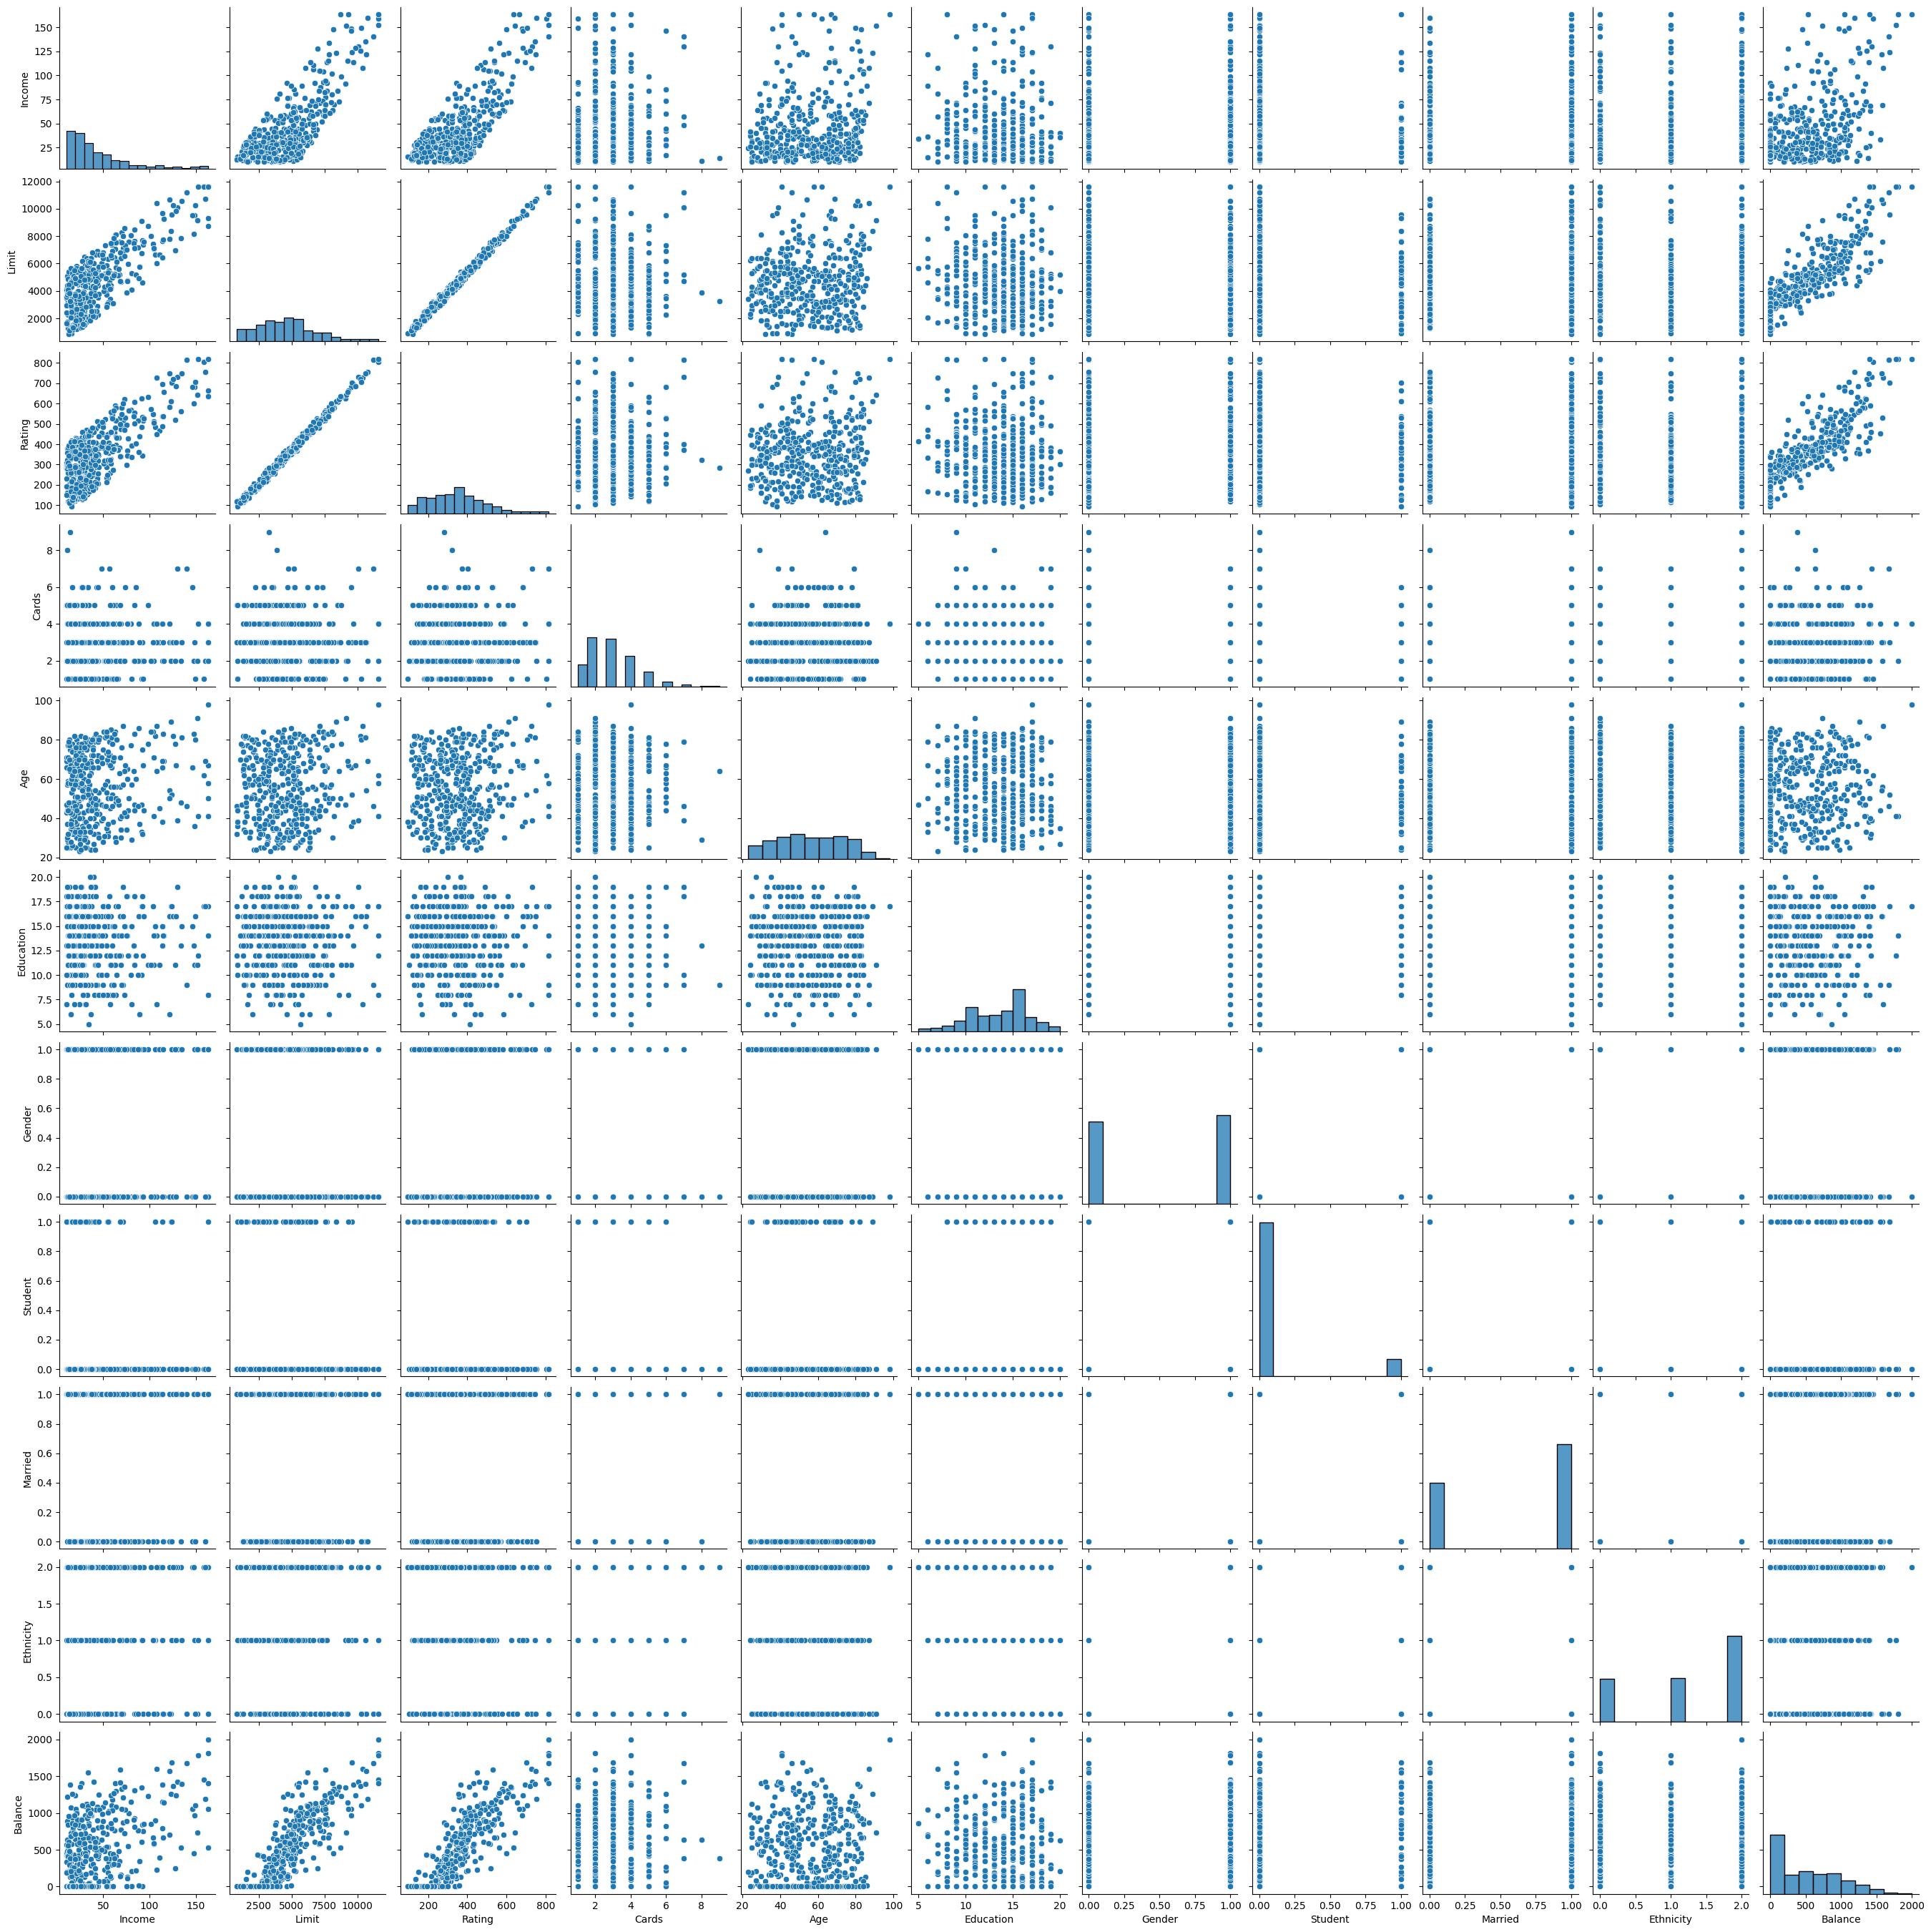

In [96]:
# prompt: plot pairplot

# Assuming df is your DataFrame as defined in the previous code

sns.pairplot(df)
plt.show()

* Step 8: Separate independent features and Target Variables

In [97]:
# prompt: seprate x and y as balance

X = df.drop('Balance', axis=1)
y = df['Balance']

In [98]:
# prompt: calculate vif score using stat model

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data

,feature,VIF
0,Income,7.192700
1,Limit,1085.398778
2,Rating,1285.833390
3,Cards,8.227682
4,Age,9.726129
5,Education,11.770405
6,Gender,2.045495
7,Student,1.141665
8,Married,2.626659
9,Ethnicity,3.127790


In [99]:
# prompt: drop rating from x

X = X.drop(columns=['Rating'])
X.head()

,Income,Limit,Cards,Age,Education,Gender,Student,Married,Ethnicity
0,14.891,3606.0,2,34,11,0,0,1,2
1,106.025,6645.0,3,82,15,1,1,1,1
2,104.593,7075.0,4,71,11,0,0,0,1
3,148.924,9504.0,3,36,11,1,0,0,1
4,55.882,4897.0,2,68,16,0,0,1,2


In [100]:
# prompt: calculate vif score using stat model

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data

,feature,VIF
0,Income,7.191101
1,Limit,13.076958
2,Cards,5.074450
3,Age,9.349181
4,Education,11.266726
5,Gender,2.036445
6,Student,1.130604
7,Married,2.557187
8,Ethnicity,3.097681


# Data splitting

In [101]:
# prompt: split into training and testing

from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% training and 20% test

In [102]:
print(X_train.shape)
print(X_test.shape)

(320, 9)
(80, 9)


* Step 9: Normalization or Standardization

In [103]:
# prompt: perform standard scaler

from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [108]:
# prompt: use OLS model for linear regression

import statsmodels.api as sm

# Add a constant to the independent variables
X_train_scaled = sm.add_constant(X_train_scaled)
X_test_scaled = sm.add_constant(X_test_scaled)

# Create and fit the OLS model
ols_model = sm.OLS(y_train, X_train_scaled).fit()

# Print the model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Balance   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     617.3
Date:                Tue, 28 Jan 2025   Prob (F-statistic):          4.10e-192
Time:                        10:19:43   Log-Likelihood:                -1953.1
No. Observations:                 320   AIC:                             3926.
Df Residuals:                     310   BIC:                             3964.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        518.8250      6.149     84.374      0.0

In [109]:
# Make predictions on the test set
y_pred = ols_model.predict(X_test_scaled)

# Evaluate the model (example: R-squared)
r_squared = ols_model.rsquared
print(f"R-squared: {r_squared}")

R-squared: 0.9471495964342824


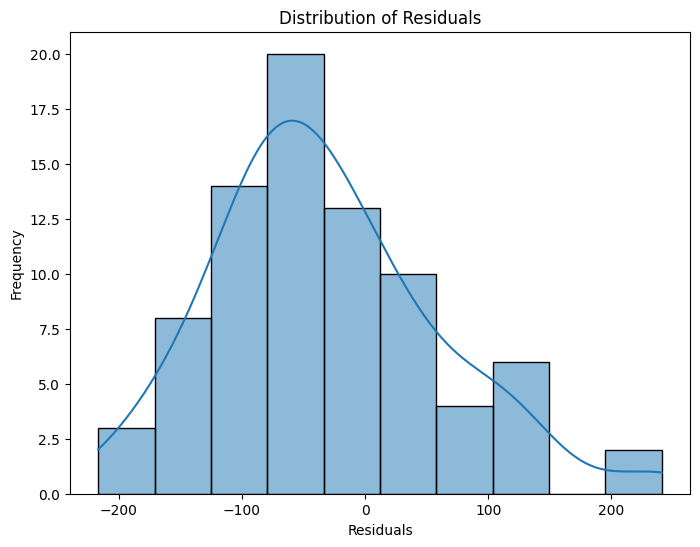

In [111]:
# prompt: plot distribution of error

# Calculate the residuals
residuals = y_test - y_pred

# Plot the distribution of errors
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


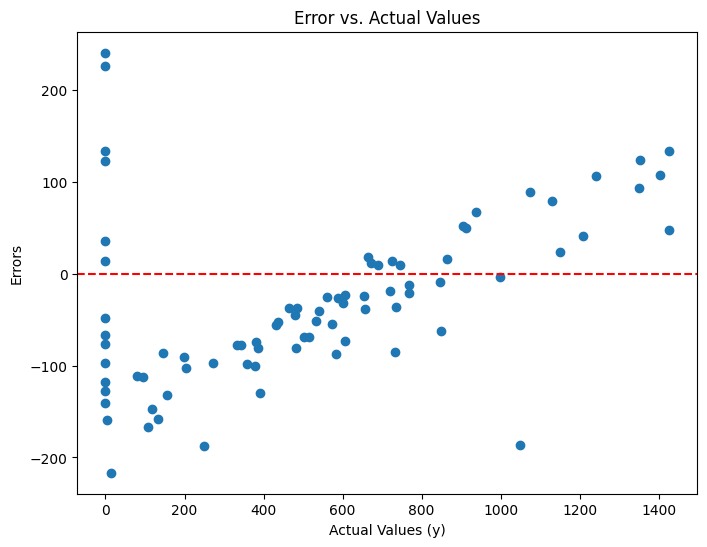

In [112]:
# prompt: plot scatter plot for error vs y

import matplotlib.pyplot as plt

# Assuming 'y_test' and 'y_pred' are already defined from your previous code

# Calculate the errors
errors = y_test - y_pred

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, errors)
plt.xlabel("Actual Values (y)")
plt.ylabel("Errors")
plt.title("Error vs. Actual Values")
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at y=0
plt.show()

In [113]:
# prompt: print coef_ along with column Name

import pandas as pd
# Assuming ols_model is your fitted statsmodels OLS model
# Access coefficients and column names
coef_df = pd.DataFrame({'feature': ols_model.params.index, 'coef': ols_model.params.values})
coef_df

,feature,coef
0,const,518.825000
1,x1,-251.645230
2,x2,615.356990
3,x3,34.614495
4,x4,-9.464445
5,x5,-2.312228
6,x6,-5.689181
7,x7,121.657976
8,x8,0.312854
9,x9,4.112717
